# So sanh ROC giua cac model

Notebook nay so sanh cac model trong dieu kien tot nhat cua tung model: dung checkpoint tot nhat da luu (`best_*.pth`), dung kich thuoc anh/test transform cua tung kien truc, roi danh gia tren cung mot test set.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    auc,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, SequentialSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b3, mobilenet_v3_large, resnet50

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Cau hinh chung

Neu notebook khong tu tim thay du lieu, dat bien moi truong `RICE_DATASET_SPLIT` tro den thu muc chua `train`, `val`, `test`.


In [2]:
PROJECT_ROOT = Path.cwd().parent  # notebook nằm trong notebooks/
CHECKPOINT_DIR = PROJECT_ROOT / "models"


def resolve_data_root():
    env_path = os.environ.get("RICE_DATASET_SPLIT")
    candidates = []
    if env_path:
        candidates.append(Path(env_path))

    candidates.extend([
        PROJECT_ROOT / "RiceDataset_Split",
        PROJECT_ROOT.parent / "RiceDataset_Split",
    ])
    if len(PROJECT_ROOT.parents) >= 2:
        candidates.append(PROJECT_ROOT.parents[1] / "RiceDataset_Split")

    for candidate in candidates:
        if (candidate / "test").exists():
            return candidate

    raise FileNotFoundError(
        "Cannot find RiceDataset_Split/test. Set RICE_DATASET_SPLIT to the dataset folder."
    )


DATA_ROOT = resolve_data_root()
TEST_DIR = DATA_ROOT / "test"
print(f"Test directory: {TEST_DIR}")

MODEL_CONFIGS = {
    "MobileNetV3": {
        "checkpoint": CHECKPOINT_DIR / "best_mobilenetv3.pth",
        "image_size": 300,
        "batch_size": 32,
        "build": lambda num_classes: build_mobilenetv3(num_classes),
    },
    "ResNet50": {
        "checkpoint": CHECKPOINT_DIR / "best_resnet50.pth",
        "image_size": 224,
        "batch_size": 64,
        "build": lambda num_classes: build_resnet50(num_classes),
    },
    "EfficientNet-B3": {
        "checkpoint": CHECKPOINT_DIR / "best_efficientnet_b3.pth",
        "image_size": 300,
        "batch_size": 16,
        "build": lambda num_classes: build_efficientnet_b3(num_classes),
    },
}

for model_name, config in MODEL_CONFIGS.items():
    if not config["checkpoint"].exists():
        raise FileNotFoundError(f"Missing checkpoint for {model_name}: {config['checkpoint']}")


Test directory: d:\KÌ 7\RiceDataset_Split\test


## Ham dung model, loader va du doan


In [3]:
def make_test_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ])


def build_mobilenetv3(num_classes):
    model = mobilenet_v3_large(weights=None)
    model.classifier[3] = torch.nn.Linear(
        model.classifier[3].in_features,
        num_classes,
    )
    return model


def build_resnet50(num_classes):
    model = resnet50(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    return model


def build_efficientnet_b3(num_classes):
    model = efficientnet_b3(weights=None)
    model.classifier[1] = torch.nn.Linear(
        model.classifier[1].in_features,
        num_classes,
    )
    return model


def torch_load_checkpoint(path, device):
    try:
        checkpoint = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def load_best_model(model_name, num_classes):
    config = MODEL_CONFIGS[model_name]
    model = config["build"](num_classes)
    state_dict = torch_load_checkpoint(config["checkpoint"], device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def make_test_dataset_and_loader(model_name):
    config = MODEL_CONFIGS[model_name]
    dataset = ImageFolder(
        TEST_DIR,
        transform=make_test_transform(config["image_size"]),
    )
    loader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=device.type == "cuda",
    )
    assert isinstance(loader.sampler, SequentialSampler), "Test loader must not shuffle samples."
    return dataset, loader


def predict_probabilities(model, loader):
    all_targets = []
    all_probabilities = []

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=device.type == "cuda")
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            all_targets.append(labels.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_prob = np.concatenate(all_probabilities)
    y_pred = y_prob.argmax(axis=1)
    return y_true, y_pred, y_prob


## Chay danh gia tung model

Moi model dung checkpoint va input size rieng, nhung class mapping va thu tu sample trong test set duoc kiem tra de so sanh cong bang.


In [4]:
base_dataset = ImageFolder(TEST_DIR, transform=make_test_transform(224))
class_names = base_dataset.classes
num_classes = len(class_names)
model_results = {}

for model_name in MODEL_CONFIGS:
    print(f"Evaluating {model_name}...")
    dataset, loader = make_test_dataset_and_loader(model_name)

    assert dataset.class_to_idx == base_dataset.class_to_idx, (
        f"Class mapping mismatch for {model_name}."
    )
    assert [path for path, _ in dataset.samples] == [path for path, _ in base_dataset.samples], (
        f"Sample order mismatch for {model_name}."
    )

    model = load_best_model(model_name, num_classes)
    y_true, y_pred, y_prob = predict_probabilities(model, loader)

    assert y_prob.shape == (len(dataset), num_classes)
    assert set(np.unique(y_true)) == set(range(num_classes)), (
        "Every class must have at least one test image for multiclass ROC-AUC."
    )

    model_results[model_name] = {
        "config": MODEL_CONFIGS[model_name],
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

print(f"Done. Evaluated {len(base_dataset):,} test images for each model.")


Evaluating MobileNetV3...
Evaluating ResNet50...
Evaluating EfficientNet-B3...
Done. Evaluated 2,499 test images for each model.


## Bang so sanh tong quan


In [5]:
summary_rows = []

for model_name, result in model_results.items():
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    y_prob = result["y_prob"]
    config = result["config"]

    summary_rows.append({
        "Model": model_name,
        "Checkpoint": config["checkpoint"].name,
        "Input size": config["image_size"],
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "ROC-AUC macro OVR": roc_auc_score(
            y_true,
            y_prob,
            labels=np.arange(num_classes),
            multi_class="ovr",
            average="macro",
        ),
        "ROC-AUC weighted OVR": roc_auc_score(
            y_true,
            y_prob,
            labels=np.arange(num_classes),
            multi_class="ovr",
            average="weighted",
        ),
    })

summary = (
    pd.DataFrame(summary_rows)
    .sort_values("ROC-AUC macro OVR", ascending=False)
    .reset_index(drop=True)
)

best_model = summary.loc[0, "Model"]
print(f"Best model by macro ROC-AUC: {best_model}")
display(summary.style.format({
    "Accuracy": "{:.4f}",
    "Precision macro": "{:.4f}",
    "Recall macro": "{:.4f}",
    "F1 macro": "{:.4f}",
    "ROC-AUC macro OVR": "{:.4f}",
    "ROC-AUC weighted OVR": "{:.4f}",
}))


Best model by macro ROC-AUC: EfficientNet-B3


,Model,Checkpoint,Input size,Accuracy,Precision macro,Recall macro,F1 macro,ROC-AUC macro OVR,ROC-AUC weighted OVR
0,EfficientNet-B3,best_efficientnet_b3.pth,300,0.8760,0.8690,0.8748,0.8712,0.9892,0.9887
1,ResNet50,best_resnet50.pth,224,0.8756,0.8700,0.8755,0.8723,0.9874,0.9875
2,MobileNetV3,best_mobilenetv3.pth,300,0.8295,0.8198,0.8379,0.8254,0.9838,0.9833


## ROC micro-average: so sanh truc tiep giua cac model

Micro-average gom tat ca one-vs-rest decision lai, phu hop de nhin nhanh model nao phan biet tong the tot hon.


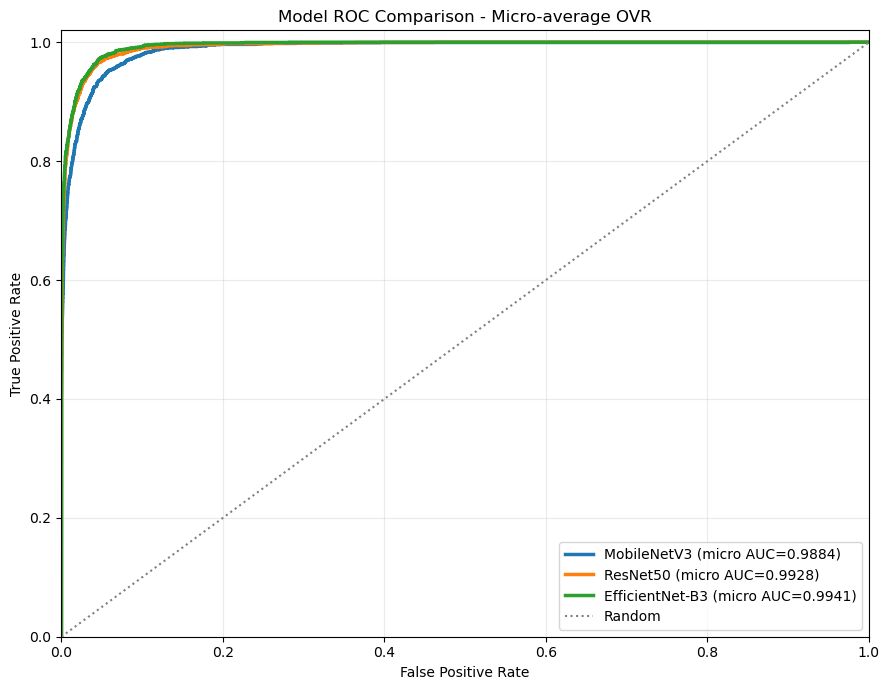

In [6]:
plt.figure(figsize=(9, 7))

for model_name, result in model_results.items():
    y_true_binary = label_binarize(
        result["y_true"],
        classes=np.arange(num_classes),
    )
    y_prob = result["y_prob"]

    fpr, tpr, _ = roc_curve(y_true_binary.ravel(), y_prob.ravel())
    micro_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, label=f"{model_name} (micro AUC={micro_auc:.4f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Random")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model ROC Comparison - Micro-average OVR")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## ROC macro-average: trung binh deu theo class

Macro-average cho moi class trong so ngang nhau, nen thuong la tieu chi cong bang hon neu cac class lech so luong.


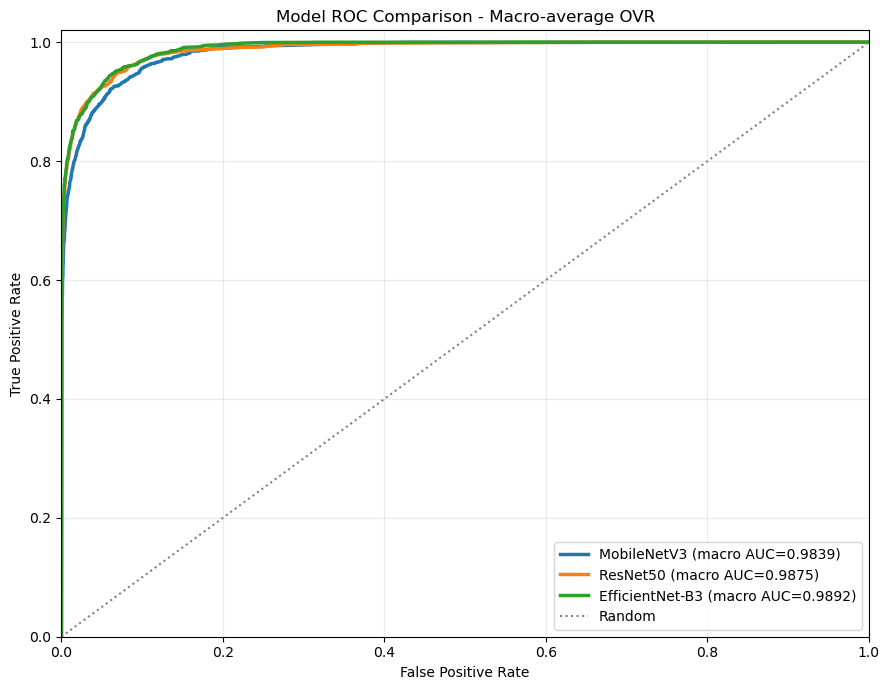

In [7]:
def macro_average_roc(y_true, y_prob, num_classes):
    y_true_binary = label_binarize(y_true, classes=np.arange(num_classes))

    class_fpr = []
    class_tpr = []
    for class_index in range(num_classes):
        fpr, tpr, _ = roc_curve(
            y_true_binary[:, class_index],
            y_prob[:, class_index],
        )
        class_fpr.append(fpr)
        class_tpr.append(tpr)

    all_fpr = np.unique(np.concatenate(class_fpr))
    mean_tpr = np.zeros_like(all_fpr)
    for fpr, tpr in zip(class_fpr, class_tpr):
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= num_classes
    mean_tpr[0] = 0.0
    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)


plt.figure(figsize=(9, 7))

for model_name, result in model_results.items():
    fpr, tpr, macro_auc = macro_average_roc(
        result["y_true"],
        result["y_prob"],
        num_classes,
    )
    plt.plot(fpr, tpr, lw=2.5, label=f"{model_name} (macro AUC={macro_auc:.4f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Random")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model ROC Comparison - Macro-average OVR")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## ROC-AUC theo tung class


In [8]:
class_auc_rows = []

for model_name, result in model_results.items():
    y_true_binary = label_binarize(
        result["y_true"],
        classes=np.arange(num_classes),
    )
    y_prob = result["y_prob"]

    for class_index, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(
            y_true_binary[:, class_index],
            y_prob[:, class_index],
        )
        class_auc_rows.append({
            "Model": model_name,
            "Class": class_name,
            "ROC-AUC": auc(fpr, tpr),
        })

class_auc = pd.DataFrame(class_auc_rows)
class_auc_pivot = class_auc.pivot(
    index="Class",
    columns="Model",
    values="ROC-AUC",
)

display(class_auc_pivot.style.format("{:.4f}").background_gradient(cmap="Blues", axis=1))


Model,EfficientNet-B3,MobileNetV3,ResNet50
Class,,,
BacterialBlight,0.9991,0.9939,0.9970
Blast,0.9986,0.9916,0.9978
BrownSpot,0.9994,0.9949,0.9987
DeadHeart,0.9995,0.9997,0.9999
Healthy,0.9997,0.9984,0.9992
LeafDamage,0.9742,0.9646,0.9682
OtherRicePests,0.9656,0.9602,0.9668
Planthopper,0.9737,0.9625,0.9716
SheathBlight,0.9999,0.9996,1.0000


## Ket luan tu dong


In [11]:
ranking_columns = [
    "Model",
    "ROC-AUC macro OVR",
    "ROC-AUC weighted OVR",
    "Accuracy",
    "F1 macro",
]

ranking = summary[ranking_columns].copy()
display(ranking.style.format({
    "ROC-AUC macro OVR": "{:.4f}",
    "ROC-AUC weighted OVR": "{:.4f}",
    "Accuracy": "{:.4f}",
    "F1 macro": "{:.4f}",
}))

leader = ranking.iloc[0]
runner_up = ranking.iloc[1] if len(ranking) > 1 else None

print(
    f"Theo ROC-AUC macro OVR, model tot nhat la {leader['Model']} "
    f"voi AUC={leader['ROC-AUC macro OVR']:.4f}."
)
if runner_up is not None:
    gap = leader["ROC-AUC macro OVR"] - runner_up["ROC-AUC macro OVR"]
    print(
        f"Chenh lech voi model dung thu hai ({runner_up['Model']}) la {gap:.4f}."
    )


,Model,ROC-AUC macro OVR,ROC-AUC weighted OVR,Accuracy,F1 macro
0,EfficientNet-B3,0.9892,0.9887,0.8760,0.8712
1,ResNet50,0.9874,0.9875,0.8756,0.8723
2,MobileNetV3,0.9838,0.9833,0.8295,0.8254


Theo ROC-AUC macro OVR, model tot nhat la EfficientNet-B3 voi AUC=0.9892.
Chenh lech voi model dung thu hai (ResNet50) la 0.0018.


In [13]:
import time


def benchmark_model(model_name, num_classes, warmup=20, runs=100):
    dataset, _ = make_test_dataset_and_loader(model_name)
    model = load_best_model(model_name, num_classes)

    image, _ = dataset[0]
    image = image.unsqueeze(0).to(device)

    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(image)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(runs):
            _ = model(image)

        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

    avg_time_ms = (end - start) / runs * 1000

    return {
        "Model": model_name,
        "Checkpoint": MODEL_CONFIGS[model_name]["checkpoint"].name,
        "Image Size": MODEL_CONFIGS[model_name]["image_size"],
        "Inference Time (ms/image)": avg_time_ms,
        "FPS": 1000 / avg_time_ms,
    }

In [14]:
benchmark_results = [
    benchmark_model(model_name, num_classes)
    for model_name in MODEL_CONFIGS
]

benchmark_df = pd.DataFrame(benchmark_results)

display(
    benchmark_df.style.format({
        "Inference Time (ms/image)": "{:.2f}",
        "FPS": "{:.2f}",
    })
)

,Model,Checkpoint,Image Size,Inference Time (ms/image),FPS
0,MobileNetV3,best_mobilenetv3.pth,300,10.45,95.73
1,ResNet50,best_resnet50.pth,224,8.36,119.68
2,EfficientNet-B3,best_efficientnet_b3.pth,300,19.79,50.54
